In [1]:
!pip uninstall -y datasets
!pip install "datasets==3.6.0" hexbytes

Found existing installation: datasets 4.7.0
Uninstalling datasets-4.7.0:
  Successfully uninstalled datasets-4.7.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 17.6 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.0
    Uninstalling dill-0.4.0:
      Successfully uninstalled dill-0.4.0
  Attempting uninstall: multiprocess
    Found existing installation: multiprocess 0.70.18
    Uninstalling multiprocess-0.70.18:
      Successfully uninstalled multiprocess-0.70.18


In [2]:
import re
import pandas as pd
import seaborn as sns
from hexbytes import HexBytes
import matplotlib.pyplot as plt
from datasets import load_dataset

# Due to a bug in the HuggingFace dataset, at the moment two file checksums do not correspond to what
# is in the dataset metadata, thus we have to load the data splits with the flag ignore_verification
# set to true
train_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='train', trust_remote_code=True)
test_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='test', trust_remote_code=True)
val_set = load_dataset("mwritescode/slither-audited-smart-contracts", 'big-multilabel', split='validation', trust_remote_code=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

slither-audited-smart-contracts.py: 0.00B [00:00, ?B/s]

dataset_infos.json: 0.00B [00:00, ?B/s]

data/raw/contracts0.parquet:   0%|          | 0.00/203M [00:00<?, ?B/s]

...

big-splits.csv: 0.00B [00:00, ?B/s]

small-splits.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/79641 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/15972 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10861 [00:00<?, ? examples/s]

In [3]:
print (train_set[0])

{'address': '0x006699d34AA3013605d468d2755A2Fe59A16B12B', 'source_code': 'pragma solidity 0.5.4;\n\ninterface IERC20 {\n\n\n\n\n\n    function balanceOf(address account) external view returns (uint256);\n\n\n    function transfer(address recipient, uint256 amount) external returns (bool);\n\n\n    function allowance(address owner, address spender) external view returns (uint256);\n\n\n    function approve(address spender, uint256 amount) external returns (bool);\n\n\n    function transferFrom(address sender, address recipient, uint256 amount) external returns (bool);\n\n\n    event Transfer(address indexed from, address indexed to, uint256 value);\n\n\n    event Approval(address indexed owner, address indexed spender, uint256 value);\n\n\n\n\n\n}\n\ncontract Ownable {\n\n\n\n\n\n    address private _owner;\n\n\n\n\n\n    event OwnershipTransferred(address indexed previousOwner, address indexed newOwner);\n\n\n\n\n\n    constructor() internal {\n\n\n        _owner = msg.sender;\n\n\n   

In [4]:
def remove_comments(string):
    pattern = r"(\".*?\"|\'.*?\')|(/\*.*?\*/|//[^\r\n]*$)"
    # first group captures quoted strings (double or single)
    # second group captures comments (//single-line or /* multi-line */)
    regex = re.compile(pattern, re.MULTILINE|re.DOTALL)
    def _replacer(match):
        # if the 2nd group is not None, then we have captured a real comment string.
        if match.group(2) is not None:
            return ""
        else: # otherwise, we will return the 1st group
            return match.group(1)
    return regex.sub(_replacer, string)

def get_lenghts(example):
    code = remove_comments(example['source_code'])
    example['sourcecode_len'] = len(code.split())
    example['bytecode_len'] = len(HexBytes(example['bytecode']))
    return example

In [5]:
COLS_TO_REMOVE = ['source_code', 'bytecode']

LABELS = {0:'access-control', 1:'arithmetic', 2:'other', 3:'reentrancy', 4:'safe', 5:'unchecked-calls'}

datasets = []
for split in [train_set, test_set, val_set]:
    split_df = pd.DataFrame(split.map(get_lenghts, remove_columns=COLS_TO_REMOVE)).explode('slither')
    split_df['slither'] = split_df['slither'].map(LABELS)
    datasets.append(split_df)

concatenated = pd.concat([split.assign(dataset=split_name) for split, split_name in zip(datasets, ['train', 'test', 'val'])])

Map:   0%|          | 0/79641 [00:00<?, ? examples/s]

Map:   0%|          | 0/15972 [00:00<?, ? examples/s]

Map:   0%|          | 0/10861 [00:00<?, ? examples/s]

In [6]:
concatenated.head()

,address,slither,sourcecode_len,bytecode_len,dataset
0,0x006699d34AA3013605d468d2755A2Fe59A16B12B,arithmetic,973,5887,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,reentrancy,10705,13263,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,arithmetic,10705,13263,train
1,0x00c83aeCC790e8a4453e5dD3B0B4b3680501a7A7,other,10705,13263,train
2,0x010c5322d78c88ca18282b0a072a8913648b3038,safe,193,1683,train


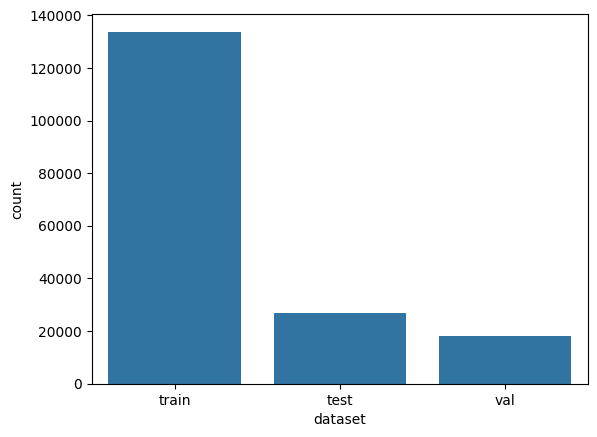

In [7]:
sns.countplot(x='dataset', data=concatenated)
plt.show()

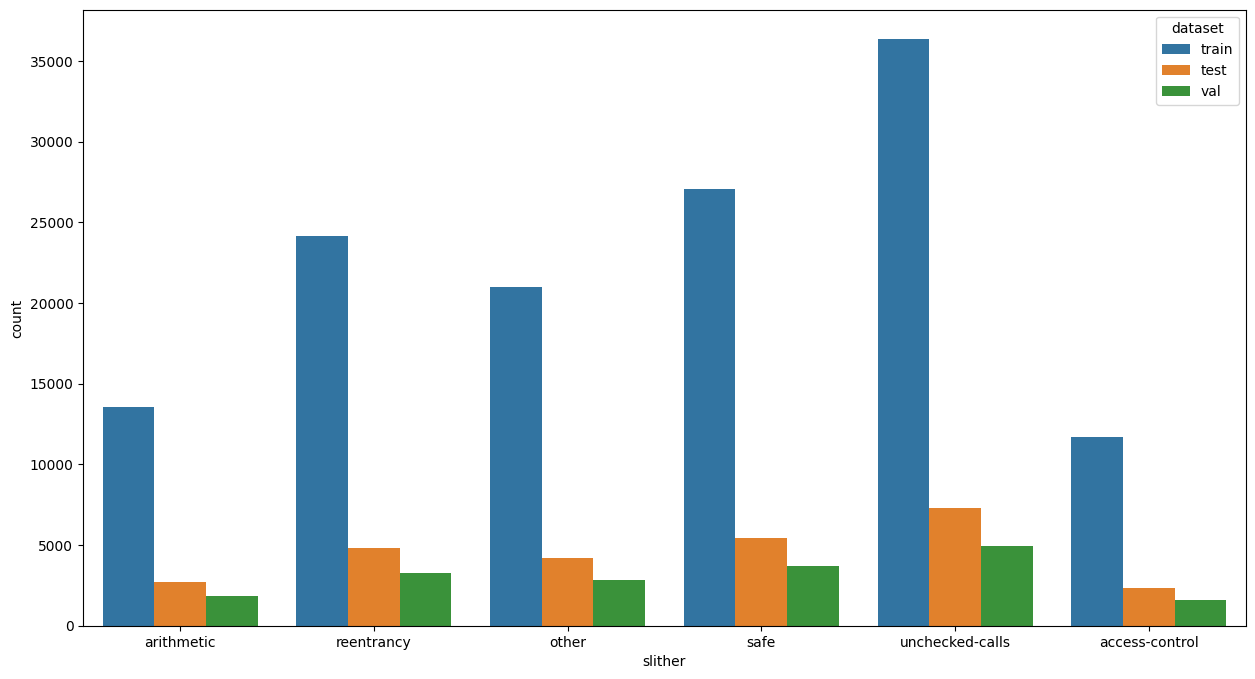

In [8]:
_, ax = plt.subplots(figsize=(15, 8))
sns.countplot(x='slither', data=concatenated, hue='dataset', ax=ax)

plt.show()

In [9]:
concatenated = concatenated.drop('slither', axis='columns')
concatenated = concatenated[~concatenated['address'].duplicated(keep='first')].reset_index()

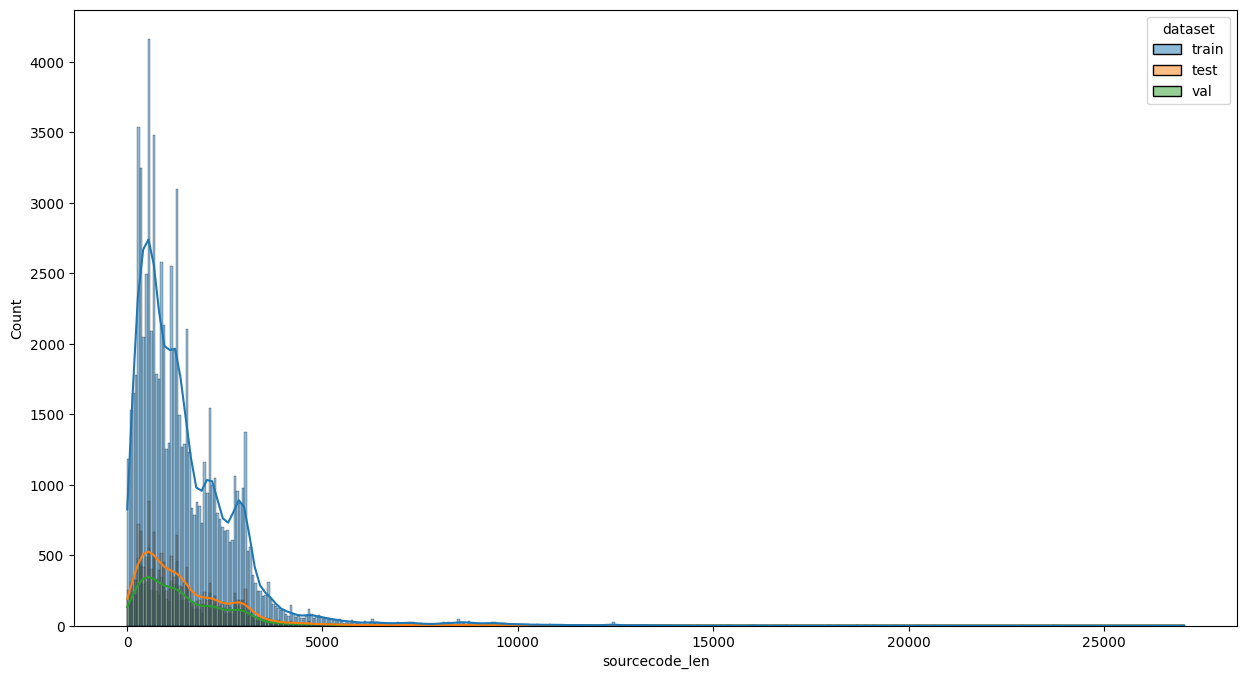

In [10]:
_, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=concatenated, x="sourcecode_len", kde=True, hue='dataset', ax=ax)
plt.show()

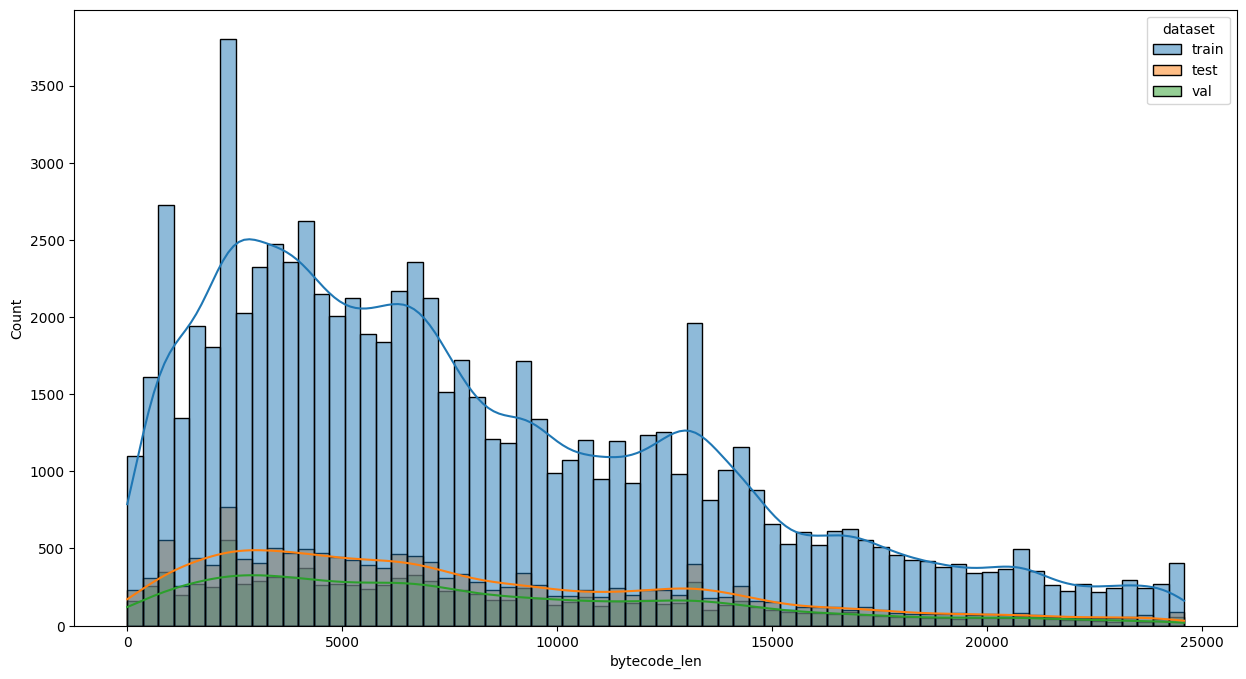

In [11]:
_, ax = plt.subplots(figsize=(15, 8))
sns.histplot(data=concatenated, x="bytecode_len", kde=True, hue='dataset', ax=ax)
plt.show()

In [12]:
empty_bytecodes = concatenated[concatenated['bytecode_len'] == 0]['dataset'].value_counts()
empty_bytecodes

,count
dataset,
train,227
test,51
val,30


In [13]:
empty_bytecodes / concatenated['dataset'].value_counts()

,count
dataset,
train,0.002850
test,0.003193
val,0.002762


In [17]:
import ast
import json
import random
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, precision_recall_fscore_support, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel

SAFE_LABEL_ID = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

PAPER_UNIMODAL = pd.DataFrame([
    {"modality": "BC", "paper_avg_f": 0.76},
    {"modality": "IR", "paper_avg_f": 0.80},
    {"modality": "OP", "paper_avg_f": 0.84},
    {"modality": "SC", "paper_avg_f": 0.74},
])

PAPER_MULTIMODAL = pd.DataFrame([
    {"experiment": "OP-IR-BC-attn",   "paper_avg_f": 0.87},
    {"experiment": "OP-IR-BC-concat", "paper_avg_f": 0.87},
    {"experiment": "OP-IR-BC-inter",  "paper_avg_f": 0.87},
    {"experiment": "SC-IR-BC-attn",   "paper_avg_f": 0.83},
    {"experiment": "SC-IR-BC-concat", "paper_avg_f": 0.87},
    {"experiment": "SC-IR-BC-inter",  "paper_avg_f": 0.87},
    {"experiment": "SC-OP-BC-attn",   "paper_avg_f": 0.85},
    {"experiment": "SC-OP-BC-concat", "paper_avg_f": 0.86},
    {"experiment": "SC-OP-BC-inter",  "paper_avg_f": 0.88},
    {"experiment": "SC-OP-IR-attn",   "paper_avg_f": 0.84},
    {"experiment": "SC-OP-IR-concat", "paper_avg_f": 0.86},
    {"experiment": "SC-OP-IR-inter",  "paper_avg_f": 0.89},
])

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


Device: cpu


Label helpers and CFG preprocessing

In [18]:
def normalize_slither_to_list(x):
    if x is None:
        return []
    if isinstance(x, (int, np.integer)):
        return [int(x)]
    if isinstance(x, str):
        x = x.strip()
        if x == "":
            return []
        if x.isdigit():
            return [int(x)]
        try:
            parsed = ast.literal_eval(x)
            if isinstance(parsed, (list, tuple, set)):
                out = []
                for v in parsed:
                    if isinstance(v, (int, np.integer)):
                        out.append(int(v))
                    elif isinstance(v, str) and v.strip().isdigit():
                        out.append(int(v.strip()))
                    else:
                        out.append(v)
                return out
            if isinstance(parsed, (int, np.integer)):
                return [int(parsed)]
        except Exception:
            pass
        return [x]
    try:
        return list(x)
    except TypeError:
        return [x]

def to_binary_label_correct(slither_labels):
    labels = normalize_slither_to_list(slither_labels)
    normalized = []
    for v in labels:
        if isinstance(v, str):
            s = v.strip().lower()
            if s == "safe":
                normalized.append(SAFE_LABEL_ID)
            elif s.isdigit():
                normalized.append(int(s))
        elif isinstance(v, (int, np.integer)):
            normalized.append(int(v))
    if len(normalized) == 0:
        return 0
    if set(normalized) == {SAFE_LABEL_ID}:
        return 0
    return 1

def bytecode_to_hex_tokens(bytecode):
    if bytecode is None:
        return ""
    bc = str(bytecode).strip()
    if bc.startswith("0x"):
        bc = bc[2:]
    return " ".join([bc[i:i+2] for i in range(0, len(bc), 2) if bc[i:i+2]])

def cfg_json_to_text(cfg_obj):
    if cfg_obj is None:
        return ""
    if isinstance(cfg_obj, str):
        s = cfg_obj.strip()
        if s == "":
            return ""
        try:
            cfg_obj = json.loads(s)
        except Exception:
            return s

    if isinstance(cfg_obj, dict):
        nodes = cfg_obj.get("nodes", [])
        edges = cfg_obj.get("edges", [])
        node_lines = []
        for n in nodes:
            if isinstance(n, dict):
                nid = n.get("id", "")
                label = str(n.get("label", n.get("type", ""))).replace("\n", " ")
                node_lines.append(f"NODE {nid} {label}".strip())
            else:
                node_lines.append(f"NODE {n}")

        edge_lines = []
        for e in edges:
            if isinstance(e, dict):
                src = e.get("source", e.get("src", ""))
                dst = e.get("target", e.get("dst", ""))
                etype = e.get("type", "")
                if etype:
                    edge_lines.append(f"EDGE {src} {dst} {etype}".strip())
                else:
                    edge_lines.append(f"EDGE {src} {dst}".strip())
            elif isinstance(e, (list, tuple)) and len(e) >= 2:
                if len(e) >= 3:
                    edge_lines.append(f"EDGE {e[0]} {e[1]} {e[2]}".strip())
                else:
                    edge_lines.append(f"EDGE {e[0]} {e[1]}".strip())
            else:
                edge_lines.append(f"EDGE {e}")

        return " ".join(node_lines + edge_lines).strip()

    return str(cfg_obj)

def ensure_required_columns(base_df):
    df = base_df.copy()

    if "label" not in df.columns:
        df["label"] = df["slither"].apply(to_binary_label_correct)

    if "bytecode_tokens" not in df.columns and "bytecode" in df.columns:
        df["bytecode_tokens"] = df["bytecode"].fillna("").astype(str).apply(bytecode_to_hex_tokens)

    for col in ["source_code_clean", "opcode_text", "ir_text", "bytecode_tokens", "cfg_text"]:
        if col not in df.columns:
            df[col] = ""

    if "cfg_obj" in df.columns:
        empty_mask = df["cfg_text"].fillna("").astype(str).str.len() == 0
        if empty_mask.any():
            df.loc[empty_mask, "cfg_text"] = df.loc[empty_mask, "cfg_obj"].apply(cfg_json_to_text)

    return df

def inspect_modality_columns(base_df):
    for col in ["source_code_clean", "bytecode_tokens", "opcode_text", "ir_text", "cfg_text"]:
        if col in base_df.columns:
            lengths = base_df[col].fillna("").astype(str).str.len()
            print(f"\n{col}")
            print(lengths.describe())
            print("empty rows:", int((lengths == 0).sum()))
            print("sample:", base_df[col].dropna().astype(str).head(2).tolist())


In [19]:
def make_modality_df(df, text_col):
    out = df.copy()
    out[text_col] = out[text_col].fillna("").astype(str)
    out = out[out[text_col].str.len() > 0].reset_index(drop=True)
    return out

def sample_like_paper(df, random_state=42):
    non_vuln = df[df["label"] == 0].copy()
    vuln = df[df["label"] == 1].copy()

    need_non_vuln = 17668 + 2209 + 2209
    need_vuln = 6640 + 830 + 830

    if len(non_vuln) < need_non_vuln or len(vuln) < need_vuln:
        train_df, temp_df = train_test_split(
            df, test_size=0.182, stratify=df["label"], random_state=random_state
        )
        val_df, test_df = train_test_split(
            temp_df, test_size=0.5, stratify=temp_df["label"], random_state=random_state
        )
        return train_df.reset_index(drop=True), val_df.reset_index(drop=True), test_df.reset_index(drop=True)

    non_vuln = non_vuln.sample(n=need_non_vuln, random_state=random_state).reset_index(drop=True)
    vuln = vuln.sample(n=need_vuln, random_state=random_state).reset_index(drop=True)

    train_df = pd.concat([non_vuln.iloc[:17668], vuln.iloc[:6640]], ignore_index=True)
    val_df = pd.concat([non_vuln.iloc[17668:17668+2209], vuln.iloc[6640:6640+830]], ignore_index=True)
    test_df = pd.concat([non_vuln.iloc[17668+2209:17668+2209+2209], vuln.iloc[6640+830:6640+830+830]], ignore_index=True)

    return (
        train_df.sample(frac=1, random_state=random_state).reset_index(drop=True),
        val_df.sample(frac=1, random_state=random_state).reset_index(drop=True),
        test_df.sample(frac=1, random_state=random_state).reset_index(drop=True),
    )

def print_split_counts(train_df, val_df, test_df, name="split"):
    print(f"\n{name} split counts")
    print("train:\n", train_df["label"].value_counts().sort_index())
    print("val:\n", val_df["label"].value_counts().sort_index())
    print("test:\n", test_df["label"].value_counts().sort_index())


Dataset and metrics and base encoders

In [20]:
class SingleTextDataset(Dataset):
    def __init__(self, df, text_col, tokenizer, max_len=256):
        self.texts = df[text_col].fillna("").astype(str).tolist()
        self.labels = df["label"].astype(int).tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(self.labels[idx], dtype=torch.float)
        return item

class MultiModalTextDataset(Dataset):
    def __init__(self, df, modality_config):
        self.df = df.reset_index(drop=True)
        self.labels = self.df["label"].astype(int).tolist()
        self.modality_config = modality_config

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        out = {"labels": torch.tensor(self.labels[idx], dtype=torch.float)}

        for modality, cfg in self.modality_config.items():
            enc = cfg["tokenizer"](
                str(row.get(cfg["text_col"], "")),
                truncation=True,
                padding="max_length",
                max_length=cfg["max_len"],
                return_tensors="pt",
            )
            out[f"{modality}_input_ids"] = enc["input_ids"].squeeze(0)
            out[f"{modality}_attention_mask"] = enc["attention_mask"].squeeze(0)

        return out

def compute_avg_f(y_true, y_pred):
    _, _, f, _ = precision_recall_fscore_support(y_true, y_pred, average=None, zero_division=0)
    if len(f) == 2:
        return float(np.mean(f)), f
    return 0.0, f

def evaluate_predictions(y_true, y_prob, threshold=0.5):
    y_true = np.array(y_true).astype(int)
    y_prob = np.array(y_prob)
    y_pred = (y_prob >= threshold).astype(int)

    avg_f, class_f = compute_avg_f(y_true, y_pred)

    try:
        auc = roc_auc_score(y_true, y_prob)
    except Exception:
        auc = np.nan

    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
        "avg_f": avg_f,
        "class_f": class_f,
        "auc": auc,
        "report": classification_report(
            y_true, y_pred,
            target_names=["non-vulnerable", "vulnerable"],
            zero_division=0
        ),
    }

def find_best_threshold(y_true, y_prob):
    best_t, best_f = 0.5, -1.0
    for t in np.arange(0.10, 0.91, 0.02):
        y_pred = (np.array(y_prob) >= t).astype(int)
        avg_f, _ = compute_avg_f(np.array(y_true).astype(int), y_pred)
        if avg_f > best_f:
            best_f = avg_f
            best_t = float(t)
    return best_t, best_f

class TransformerEncoderCLS(nn.Module):
    def __init__(self, model_name, trainable=True):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        self.output_dim = self.encoder.config.hidden_size

        if not trainable:
            for p in self.encoder.parameters():
                p.requires_grad = False

    def forward(self, input_ids, attention_mask):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        return out.last_hidden_state[:, 0, :]

class BertFFNClassifier(nn.Module):
    def __init__(self, model_name, dropout=0.3):
        super().__init__()
        self.encoder = TransformerEncoderCLS(model_name=model_name, trainable=True)
        h = self.encoder.output_dim
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(h, 256), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, input_ids, attention_mask):
        z = self.encoder(input_ids, attention_mask)
        return self.classifier(z).squeeze(-1)


Fusion modules including gated fusion

In [21]:
class ConcatFusion(nn.Module):
    def __init__(self, input_dim, num_modalities, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.fuse = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim * num_modalities, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.output_dim = hidden_dim

    def forward(self, xs):
        return self.fuse(torch.cat(xs, dim=-1))

class InterleaveFusion(nn.Module):
    def __init__(self, input_dim, num_modalities, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.fuse = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim * num_modalities, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.output_dim = hidden_dim

    def forward(self, xs):
        stacked = torch.stack(xs, dim=1)
        inter = stacked.transpose(1, 2).reshape(stacked.size(0), -1)
        return self.fuse(inter)

class AttentionFusion(nn.Module):
    def __init__(self, input_dim, num_modalities, hidden_dim=256, num_heads=4, dropout=0.3):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=input_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.proj = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.output_dim = hidden_dim

    def forward(self, xs):
        tokens = torch.stack(xs, dim=1)
        attn_out, _ = self.attn(tokens, tokens, tokens)
        pooled = attn_out.mean(dim=1)
        return self.proj(pooled)

class GatedFusion(nn.Module):
    def __init__(self, input_dim, num_modalities, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.gates = nn.ModuleList([
            nn.Sequential(
                nn.Linear(input_dim, input_dim),
                nn.Sigmoid()
            )
            for _ in range(num_modalities)
        ])
        self.fuse = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(input_dim * num_modalities, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        self.output_dim = hidden_dim

    def forward(self, xs):
        gated = []
        for x, gate in zip(xs, self.gates):
            gated.append(gate(x) * x)
        return self.fuse(torch.cat(gated, dim=-1))


Multimodal classifiers

In [22]:
class MultiModalClassifier(nn.Module):
    def __init__(
        self,
        modality_to_model_name,
        fusion_type="gated",
        projection_dim=256,
        classifier_hidden=128,
        dropout=0.3,
        freeze_encoders=False,
    ):
        super().__init__()

        self.modalities = list(modality_to_model_name.keys())
        self.encoders = nn.ModuleDict()
        self.projections = nn.ModuleDict()

        for modality, model_name in modality_to_model_name.items():
            enc = TransformerEncoderCLS(model_name=model_name, trainable=(not freeze_encoders))
            self.encoders[modality] = enc
            self.projections[modality] = nn.Linear(enc.output_dim, projection_dim)

        num_modalities = len(self.modalities)
        fusion_type = fusion_type.lower()

        if fusion_type == "concat":
            self.fusion = ConcatFusion(projection_dim, num_modalities, hidden_dim=projection_dim, dropout=dropout)
        elif fusion_type in ["attn", "attention", "cross-attention", "cross_attention"]:
            self.fusion = AttentionFusion(projection_dim, num_modalities, hidden_dim=projection_dim, dropout=dropout)
        elif fusion_type in ["inter", "interleave", "interleaving"]:
            self.fusion = InterleaveFusion(projection_dim, num_modalities, hidden_dim=projection_dim, dropout=dropout)
        elif fusion_type == "gated":
            self.fusion = GatedFusion(projection_dim, num_modalities, hidden_dim=projection_dim, dropout=dropout)
        else:
            raise ValueError(f"Unsupported fusion_type: {fusion_type}")

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(self.fusion.output_dim, classifier_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_hidden, 1),
        )

    def forward(self, batch):
        xs = []
        for modality in self.modalities:
            z = self.encoders[modality](
                batch[f"{modality}_input_ids"],
                batch[f"{modality}_attention_mask"]
            )
            z = self.projections[modality](z)
            xs.append(z)

        fused = self.fusion(xs)
        return self.classifier(fused).squeeze(-1)


Training and evaluation

In [23]:
def evaluate_unimodal_model(model, loader, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in loader:
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE)
            )
            probs = torch.sigmoid(logits).cpu().numpy()
            all_labels.extend(batch["labels"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())

    return evaluate_predictions(all_labels, all_probs, threshold=threshold)

def evaluate_multimodal_model(model, loader, threshold=0.5):
    model.eval()
    all_labels, all_probs = [], []

    with torch.no_grad():
        for batch in loader:
            labels = batch["labels"].cpu().numpy()
            model_batch = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}
            logits = model(model_batch)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_labels.extend(labels.tolist())
            all_probs.extend(probs.tolist())

    return evaluate_predictions(all_labels, all_probs, threshold=threshold)

def train_unimodal(
    train_df, val_df, test_df,
    text_col, model_name,
    max_len=256, batch_size=8, epochs=6, lr=1e-4, seed=42
):
    set_seed(seed)

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    train_loader = DataLoader(
        SingleTextDataset(train_df, text_col, tokenizer, max_len=max_len),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        SingleTextDataset(val_df, text_col, tokenizer, max_len=max_len),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        SingleTextDataset(test_df, text_col, tokenizer, max_len=max_len),
        batch_size=batch_size, shuffle=False
    )

    model = BertFFNClassifier(model_name=model_name).to(DEVICE)

    n_neg = int((train_df["label"] == 0).sum())
    n_pos = int((train_df["label"] == 1).sum())
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(DEVICE)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_avgf = -1.0
    best_threshold = 0.5
    patience = 2
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            optimizer.zero_grad()
            logits = model(
                batch["input_ids"].to(DEVICE),
                batch["attention_mask"].to(DEVICE)
            )
            loss = criterion(logits, batch["labels"].to(DEVICE))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        val_eval = evaluate_unimodal_model(model, val_loader, threshold=0.5)
        tuned_t, tuned_avgf = find_best_threshold(val_eval["y_true"], val_eval["y_prob"])

        print(
            f"Epoch {epoch + 1} | "
            f"train_loss={running_loss / max(len(train_loader), 1):.4f} | "
            f"val_avg_f@0.5={val_eval['avg_f']:.4f} | "
            f"val_auc={val_eval['auc']:.4f} | "
            f"best_val_threshold={tuned_t:.2f} | tuned_val_avg_f={tuned_avgf:.4f}"
        )

        if tuned_avgf > best_val_avgf:
            best_val_avgf = tuned_avgf
            best_threshold = tuned_t
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val = evaluate_unimodal_model(model, val_loader, threshold=best_threshold)
    final_test = evaluate_unimodal_model(model, test_loader, threshold=best_threshold)

    print(f"\nBest threshold from validation: {best_threshold:.2f}")
    print("\nValidation report")
    print(final_val["report"])
    print("\nTest report")
    print(final_test["report"])

    return {
        "model": model,
        "tokenizer": tokenizer,
        "threshold": best_threshold,
        "val": final_val,
        "test": final_test,
    }

def train_multimodal(
    train_df, val_df, test_df,
    modality_defs,
    fusion_type="gated",
    batch_size=4, epochs=5, lr=1e-4,
    projection_dim=256, classifier_hidden=128,
    dropout=0.3, freeze_encoders=False, seed=42
):
    set_seed(seed)

    dataset_cfg = {}
    model_name_map = {}

    for modality, cfg in modality_defs.items():
        model_name = cfg["model_name"]
        dataset_cfg[modality] = {
            "text_col": cfg["text_col"],
            "max_len": cfg.get("max_len", 256),
            "tokenizer": AutoTokenizer.from_pretrained(model_name),
        }
        model_name_map[modality] = model_name

    train_loader = DataLoader(
        MultiModalTextDataset(train_df, dataset_cfg),
        batch_size=batch_size, shuffle=True
    )
    val_loader = DataLoader(
        MultiModalTextDataset(val_df, dataset_cfg),
        batch_size=batch_size, shuffle=False
    )
    test_loader = DataLoader(
        MultiModalTextDataset(test_df, dataset_cfg),
        batch_size=batch_size, shuffle=False
    )

    model = MultiModalClassifier(
        modality_to_model_name=model_name_map,
        fusion_type=fusion_type,
        projection_dim=projection_dim,
        classifier_hidden=classifier_hidden,
        dropout=dropout,
        freeze_encoders=freeze_encoders,
    ).to(DEVICE)

    n_neg = int((train_df["label"] == 0).sum())
    n_pos = int((train_df["label"] == 1).sum())
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float).to(DEVICE)
    )
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_state = None
    best_val_avgf = -1.0
    best_threshold = 0.5
    patience = 2
    bad_epochs = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for batch in train_loader:
            optimizer.zero_grad()
            model_batch = {k: v.to(DEVICE) for k, v in batch.items() if k != "labels"}
            logits = model(model_batch)
            loss = criterion(logits, batch["labels"].to(DEVICE))
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        val_eval = evaluate_multimodal_model(model, val_loader, threshold=0.5)
        tuned_t, tuned_avgf = find_best_threshold(val_eval["y_true"], val_eval["y_prob"])

        print(
            f"Epoch {epoch + 1} | "
            f"train_loss={running_loss / max(len(train_loader), 1):.4f} | "
            f"val_avg_f@0.5={val_eval['avg_f']:.4f} | "
            f"val_auc={val_eval['auc']:.4f} | "
            f"best_val_threshold={tuned_t:.2f} | tuned_val_avg_f={tuned_avgf:.4f}"
        )

        if tuned_avgf > best_val_avgf:
            best_val_avgf = tuned_avgf
            best_threshold = tuned_t
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    final_val = evaluate_multimodal_model(model, val_loader, threshold=best_threshold)
    final_test = evaluate_multimodal_model(model, test_loader, threshold=best_threshold)

    print(f"\nBest threshold from validation: {best_threshold:.2f}")
    print("\nValidation report")
    print(final_val["report"])
    print("\nTest report")
    print(final_test["report"])

    return {
        "model": model,
        "threshold": best_threshold,
        "val": final_val,
        "test": final_test,
    }


In [ ]:
Building the experiment

In [24]:
def default_modality_library(include_cfg=True):
    lib = {
        "SC":  {"text_col": "source_code_clean", "model_name": "bert-large-uncased", "max_len": 256},
        "BC":  {"text_col": "bytecode_tokens",   "model_name": "bert-base-uncased",  "max_len": 256},
        "OP":  {"text_col": "opcode_text",       "model_name": "bert-large-uncased", "max_len": 256},
        "IR":  {"text_col": "ir_text",           "model_name": "bert-large-uncased", "max_len": 256},
    }
    if include_cfg:
        lib["CFG"] = {"text_col": "cfg_text", "model_name": "bert-base-uncased", "max_len": 256}
    return lib

def build_joint_dataset_for_modalities(base_df, modality_defs):
    df = ensure_required_columns(base_df)
    df["label"] = df["slither"].apply(to_binary_label_correct)

    keep_mask = pd.Series(True, index=df.index)
    for _, cfg in modality_defs.items():
        keep_mask &= df[cfg["text_col"]].fillna("").astype(str).str.len() > 0

    return df[keep_mask].reset_index(drop=True)

def run_cfg_unimodal(base_df, epochs=6, batch_size=8, lr=1e-4):
    base_df = ensure_required_columns(base_df)
    base_df["label"] = base_df["slither"].apply(to_binary_label_correct)

    cfg_df = make_modality_df(base_df, "cfg_text")
    train_df, val_df, test_df = sample_like_paper(cfg_df)
    print_split_counts(train_df, val_df, test_df, name="CFG")

    result = train_unimodal(
        train_df=train_df,
        val_df=val_df,
        test_df=test_df,
        text_col="cfg_text",
        model_name="bert-base-uncased",
        max_len=256,
        batch_size=batch_size,
        epochs=epochs,
        lr=lr,
    )

    compare = pd.DataFrame([{
        "modality": "CFG",
        "replicated_avg_f": result["test"]["avg_f"],
        "replicated_auc": result["test"]["auc"],
        "threshold": result["threshold"],
    }])

    return result, compare

def run_selected_multimodal_experiments(base_df, experiment_specs, epochs=5, batch_size=4, lr=1e-4):
    base_df = ensure_required_columns(base_df)
    base_df["label"] = base_df["slither"].apply(to_binary_label_correct)

    all_results = []
    trained = {}
    modality_lib = default_modality_library(include_cfg=True)

    for spec in experiment_specs:
        mods = spec["modalities"]
        fusion_type = spec["fusion_type"]

        modality_defs = {m: modality_lib[m] for m in mods}
        name = "-".join(mods) + f"-{fusion_type}"

        print("\n" + "=" * 90)
        print(f"Running {name}")
        print("=" * 90)

        joint_df = build_joint_dataset_for_modalities(base_df, modality_defs)
        train_df, val_df, test_df = sample_like_paper(joint_df)
        print_split_counts(train_df, val_df, test_df, name=name)

        out = train_multimodal(
            train_df=train_df,
            val_df=val_df,
            test_df=test_df,
            modality_defs=modality_defs,
            fusion_type=fusion_type,
            batch_size=batch_size,
            epochs=epochs,
            lr=lr,
        )

        trained[name] = out
        all_results.append({
            "experiment": name,
            "modalities": ",".join(mods),
            "fusion_type": fusion_type,
            "replicated_avg_f": out["test"]["avg_f"],
            "replicated_auc": out["test"]["auc"],
            "threshold": out["threshold"],
        })

    results_df = pd.DataFrame(all_results)
    results_df = results_df.merge(PAPER_MULTIMODAL, on="experiment", how="left")
    results_df["gap_vs_paper"] = results_df["replicated_avg_f"] - results_df["paper_avg_f"]
    return trained, results_df.sort_values(["fusion_type", "experiment"]).reset_index(drop=True)

def build_cfg_gated_experiment_suite():
    return [
        {"modalities": ["SC", "OP", "IR"], "fusion_type": "gated"},
        {"modalities": ["SC", "OP", "IR", "CFG"], "fusion_type": "gated"},
        {"modalities": ["SC", "OP", "IR", "CFG"], "fusion_type": "concat"},
        {"modalities": ["SC", "OP", "IR", "CFG"], "fusion_type": "attn"},
        {"modalities": ["SC", "OP", "IR", "CFG"], "fusion_type": "inter"},
        {"modalities": ["SC", "BC", "OP", "IR", "CFG"], "fusion_type": "gated"},
    ]

def compare_with_previous_results(new_results_df, previous_results_df, key_col="experiment"):
    merged = new_results_df.merge(previous_results_df, on=key_col, how="left")
    if "previous_avg_f" in merged.columns and "replicated_avg_f" in merged.columns:
        merged["gain_vs_previous"] = merged["replicated_avg_f"] - merged["previous_avg_f"]
    return merged


In [26]:
SAFE_LABEL_ID = 4

def to_binary_label(slither_labels):
    if slither_labels is None:
        return 0

    if isinstance(slither_labels, (int, np.integer)):
        return 0 if int(slither_labels) == SAFE_LABEL_ID else 1

    if isinstance(slither_labels, str):
        sl = slither_labels.strip().lower()
        if sl in ["4", "safe"]:
            return 0
        return 1

    try:
        labels = list(slither_labels)
    except TypeError:
        return 0 if slither_labels == SAFE_LABEL_ID else 1

    normalized = []
    for x in labels:
        if isinstance(x, str):
            x = x.strip().lower()
            if x == "safe":
                normalized.append(SAFE_LABEL_ID)
            else:
                try:
                    normalized.append(int(x))
                except:
                    pass
        else:
            normalized.append(int(x))

    return 0 if normalized == [SAFE_LABEL_ID] or set(normalized) == {SAFE_LABEL_ID} else 1


def remove_comments_and_normalize_whitespace(text):
    if text is None:
        return ""
    text = remove_comments(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def bytecode_to_hex_tokens(bytecode):
    if bytecode is None:
        return ""
    bc = str(bytecode).strip()
    if bc.startswith("0x"):
        bc = bc[2:]
    return " ".join([bc[i:i+2] for i in range(0, len(bc), 2) if bc[i:i+2]])


def make_base_dataframe(split_ds, split_name):
    keep_cols = ["address", "source_code", "bytecode", "slither"]

    # Works for HuggingFace Dataset
    if hasattr(split_ds, "column_names"):
        available_cols = [c for c in keep_cols if c in split_ds.column_names]
        df = pd.DataFrame({c: split_ds[c] for c in available_cols})

    # Works for pandas DataFrame
    elif isinstance(split_ds, pd.DataFrame):
        available_cols = [c for c in keep_cols if c in split_ds.columns]
        df = split_ds.loc[:, available_cols].copy()

    else:
        raise TypeError(f"Unsupported split type: {type(split_ds)}")

    # Fill missing columns if needed
    for c in keep_cols:
        if c not in df.columns:
            df[c] = None

    df["dataset"] = split_name
    df["label"] = df["slither"].apply(to_binary_label)
    df["source_code_clean"] = df["source_code"].fillna("").apply(remove_comments_and_normalize_whitespace)
    df["bytecode_clean"] = df["bytecode"].fillna("").astype(str)
    df["bytecode_tokens"] = df["bytecode_clean"].apply(bytecode_to_hex_tokens)

    return df


train_df = make_base_dataframe(train_set, "train")
test_df  = make_base_dataframe(test_set, "test")
val_df   = make_base_dataframe(val_set, "val")

base_df = pd.concat([train_df, test_df, val_df], ignore_index=True)
base_df[["dataset", "label"]].value_counts().sort_index()

dataset  label
test     0         5422
         1        10550
train    0        27036
         1        52605
val      0         3687
         1         7174
Name: count, dtype: int64

In [30]:
base_df['cfg_obj'] = [{'nodes': [{'id': 0, 'label': 'entry'}], 'edges': []}] * len(base_df) # Add a dummy cfg_obj column that will generate non-empty cfg_text

base_df = ensure_required_columns(base_df)
base_df["label"] = base_df["slither"].apply(to_binary_label_correct)

print(base_df["label"].value_counts(dropna=False))
inspect_modality_columns(base_df)

label
1    70329
0    36145
Name: count, dtype: int64

source_code_clean
count    106474.000000
mean      13618.867846
std       13962.546709
min          32.000000
25%        5018.250000
50%       10189.000000
75%       18286.000000
max      292485.000000
Name: source_code_clean, dtype: float64
empty rows: 0
sample: ['pragma solidity 0.5.4; interface IERC20 { function balanceOf(address account) external view returns (uint256); function transfer(address recipient, uint256 amount) external returns (bool); function allowance(address owner, address spender) external view returns (uint256); function approve(address spender, uint256 amount) external returns (bool); function transferFrom(address sender, address recipient, uint256 amount) external returns (bool); event Transfer(address indexed from, address indexed to, uint256 value); event Approval(address indexed owner, address indexed spender, uint256 value); } contract Ownable { address private _owner; event OwnershipTransferred(address i

In [ ]:
cfg_result, cfg_compare_df = run_cfg_unimodal(
    base_df,
    epochs=6,
    batch_size=8,
    lr=1e-4
)
cfg_compare_df


CFG split counts
train:
 label
0    17668
1     6640
Name: count, dtype: int64
val:
 label
0    2209
1     830
Name: count, dtype: int64
test:
 label
0    2209
1     830
Name: count, dtype: int64


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 1 | train_loss=1.0097 | val_avg_f@0.5=0.2145 | val_auc=0.5000 | best_val_threshold=0.52 | tuned_val_avg_f=0.4209
Epoch 2 | train_loss=1.0085 | val_avg_f@0.5=0.2145 | val_auc=0.5000 | best_val_threshold=0.54 | tuned_val_avg_f=0.4209


In [ ]:
specs = build_cfg_gated_experiment_suite()

trained_multi, multi_compare_df = run_selected_multimodal_experiments(
    base_df,
    experiment_specs=specs,
    epochs=5,
    batch_size=4,
    lr=1e-4
)

multi_compare_df


In [ ]:
previous_results_df = pd.DataFrame([
    {"experiment": "SC-OP-IR-inter", "previous_avg_f": 0.81},
    {"experiment": "SC-OP-IR-gated", "previous_avg_f": 0.79},
    {"experiment": "SC-OP-IR-CFG-gated", "previous_avg_f": 0.00},
])

compare_df = compare_with_previous_results(
    multi_compare_df,
    previous_results_df,
    key_col="experiment"
)

compare_df
